数据分布偏移是一个在机器学习本地部署时常常遇见的问题;一些工作者往往拿到数据后,直接套用模型开始训练,没有考虑到数据分布偏移产生的问题.

一般而言,常见的数据分布偏移有以下几种情况:

1.训练集的输入变量的分布$p(x)$与测试集的输入变量的分布$q(x)$不同,即$q(x) \neq p(x)$,此时我们要对输入变量的分布进行调整,这种情况称为协变量偏移(Covariate Shift).

2.训练集的标签分布$p(y)$与测试集的标签分布$q(y)$不同,即$q(y) \neq p(y)$,此时我们要对标签的分布进行调整,这种情况称为标签偏移(Label Shift).

3.还有一种较为少见的情况,训练集的条件分布$p(x|y)$与测试集的条件分布$q(x|y)$不同,即$q(x|y) \neq p(x|y)$,这种情况称为条件分布偏移(Conditional Distribution Shift)也称概念偏移.

### 协变量偏移修正
对于第一种情况,我们采用如下操作:

考虑一个分类问题,假设训练集和测试集的标签分布相同,即$p(y) = q(y)$,但输入变量的分布不同,即$q(x) \neq p(x)$.假设训练集的损失期望可以写成
$$
E(l(f(\mathbf{x}),y),y)=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(y,\mathbf{x}) d\mathbf{x} d y=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(y|\mathbf{x})p(\mathbf{x}) d\mathbf{x} d y
$$

同时由于类别的条件分布不变,故我们还可以将上式写为
$$
E(l(f(\mathbf{x}),y))=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(y|\mathbf{x})p(\mathbf{x}) d\mathbf{x} d y=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) q(y|\mathbf{x})q(\mathbf{x}) \frac{p(\mathbf{x})}{q(\mathbf{x})}d\mathbf{x} d y
$$

我们令
$$
\beta _i\stackrel{\mathrm{def}}{=}\frac{p(x_i)}{q(x_i)}
$$

同时,我们将上述积分式离散化,同时,使损失期望最小,最终我们有
$$
\text{minimize}_f\frac{1}{n}\sum_{i=1}^n \beta _i l(f(x_i),y_i)
$$

上式在统计学中也被称为经验损失.

现在问题来到如何确定$\beta_i$,一种常见的想法为logistic回归,这是一种Softmax回归的退化情况,专门用于处理二元分类的问题.根据上述说法,我们可以将目标分布的数据集标记为1,源分布的数据集标记为0,然后训练一个logistic回归模型,使得模型的预测值与标签的分布尽量一致.

考虑我们分别从$p(x)$分布和$q(x)$分布中抽取m和n个样本,故我们抽到标签为1(也即源分布)的数据的概率为
$$
P(z=1|\mathbf{x})=\frac{P(z=1,\mathbf{x})}{P(\mathbf{x})}=\frac{P(z=1,\mathbf{x})}{P(z=1,\mathbf{x})+P(z=0,\mathbf{x})}\\
=\frac{P(\mathbf{x}|z=1)P(z=1)}{P(\mathbf{x}|z=1)P(z=1)+P(\mathbf{x}|z=0)P(z=0)}
$$
注意到上式中
$$
P(z=1)=\frac{m}{m+n},P(z=0)=\frac{n}{m+n}\\
P(\mathbf{x}|z=1)=p(\mathbf{x}),P(\mathbf{x}|z=0)=q(\mathbf{x})
$$

带入概率公式,我们可以得到
$$
P(z=1|\mathbf{x})=\frac{mp(\mathbf{x})}{mp(\mathbf{x})+nq(\mathbf{x})}=\frac{m\frac{p(\mathbf{x})}{q(\mathbf{x})}}{m\frac{p(\mathbf{x})}{q(\mathbf{x})}+n}=\frac{m\bold{\beta}}{m\mathbf{\beta}+n}
$$

同时,该概率公式也可通过上文提到的logistic回归模型得到,即
$$
P(z=1|\mathbf{x})=\frac{1}{1+\text{e}^{-h(\mathbf{x})}}
$$

其中$h(x)$为参数函数,由Logistic回归模型学习得到.

对比上述两式,得到
$$
\frac{1}{1+\text{e}^{-h(\mathbf{x})}}=\frac{m\bold{\beta}}{m\mathbf{\beta}+n}=\frac{1}{1+\frac{n}{m}\beta ^{-1}}\\
\Longrightarrow \text{e}^{-h(\mathbf{x})}=(\frac{m}{n}\beta )^{-1}
$$

故我们可以得到
$$
\beta=\frac{n}{m}\text{e}^{h(\mathbf(x))}
$$

最终,我们的损失函数可以写为
$$
\text{minimize}_f\frac{1}{n}\sum_{i=1}^n \frac{n}{m}\text{e}^{h(x_i)} l(f(x_i),y_i)
$$

### 标签变量偏移修正
对于第二种情况,我们有类似的操作:
$$
E(l(f(\mathbf{x}),y))=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(\mathbf{x}|y)p(y) d\mathbf{x} d y=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) q(\mathbf{x}|y)q(y) \frac{p(y)}{q(y)}d\mathbf{x} d y\\
\Longrightarrow \text{minimize}_f\frac{1}{n}\sum_{i=1}^n \beta _i l(f(x_i),y_i),\quad \beta _i\stackrel{\mathrm{def}}{=}\frac{p(y_i)}{q(y_i)}
$$

一个非常棒的事情是,标签往往是低维,故其对应的分布$q(y)$是极易求得的,问题变为如何求得$p(y)$,即目标分布的标签分布.

考虑一个极强的假设,即训练集与测试集的条件分布严格相等,故我们可以认为模型在这两个数据集上输出的各个分类的概率分布是相同的.换句话说,我们在训练集上得到平均模型输出概率$$\mu(\mathbf{\hat{y}})=\frac{1}{N}\sum_{k=1}^{N} \mathbf{\hat{y}}_k$$
与在测试集得到输出概率应该完全相同,也即
$$
\mathbf{C}p(\mathbf{x})=\mu (\mathbf{\hat{y}})
$$

其中$\mathbf{C}$为训练集的混淆矩阵,同样由于训练集与测试集的条件分布应该严格相等,故两个数据集的混淆矩阵应该也严格相等.特别地,当$\mathbf{C}$可逆时,我们有

$$
p(\mathbf{x})=\mathbf{C}^{-1}\mu (\mathbf{\hat{y}})
$$

故我们有
$$
\beta=\frac{\mathbf{C}^{-1}\frac{1}{N}\sum_{k=1}^{N} \mathbf{\hat{y}}_k}{q(\mathbf{y})}
$$

最终,我们的损失函数可以写为
$$
\text{minimize}_f\frac{1}{n}\frac{c_{ik}\frac{1}{N}\sum_{k=1}^{N} \hat{y}_{ik}}{q(y_i)} l(f(x_i),y_i)
$$

### 条件分布偏移修正

该种情况发生的较少,一般直接采用训练集的条件分布$p(x|y)$来训练模型,而测试集的条件分布$q(x|y)$则不用考虑.

In [11]:
import numpy as np
import torch
import torch.nn as nn
from d2l import torch as d2l
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
def genertated_data(w, b, num_examples,is_train=True):  #@save
    """生成y = Xw + b + 噪声。"""
    if is_train==True:
        X= torch.normal(0, 1, (num_examples, len(w)))
    else:
        X= torch.normal(10, 3, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))


In [13]:
real_w =torch.tensor([2, -3.4, 3.6])
real_b =4.2

train_features, train_labels = genertated_data(real_w, real_b, 10000,is_train=True)
test_features, test_labels = genertated_data(real_w, real_b, 200,is_train=False)


In [14]:
# from torch import nn
# from tqdm  import tqdm
# net = nn.Sequential(nn.Linear(3, 1))
# net[0].weight.data.normal_(0, 0.01)
# net[0].bias.data.fill_(0)
# loss=nn.MSELoss()
# trainer = torch.optim.Adam(net.parameters(), lr=0.1)
# num_epochs=10
# batch_size=5

# for epoch in tqdm(range(num_epochs)):
#     for X, y in train_iter:
#         l = loss(net(X), y)
#         trainer.zero_grad()
#         l.backward()
#         trainer.step()
#     with torch.no_grad():
#         train_l = loss(net(train_features), train_labels)
#         print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

# print('训练已完成,参数估计为:', net[0].weight.data.reshape(-1), net[0].bias.data)

weight: [[ 2.008313  -3.4141161  3.59539  ]]


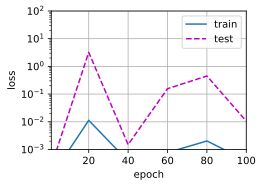

In [15]:
from utils.tool import train_regression
train_regression(0.1,train_features,test_features,train_labels,test_labels,100,True)